In [1]:
import os
import gzip
import time
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
base_url='https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/'
files=['train-images-idx3-ubyte.gz','train-labels-idx1-ubyte.gz','t10k-images-idx3-ubyte.gz','t10k-labels-idx1-ubyte.gz']
os.makedirs('fashion_mnist_data',exist_ok=True)
for f in files:
    path=os.path.join('fashion_mnist_data',f)
    if not os.path.exists(path):
        urllib.request.urlretrieve(base_url+f,path)

def load_images(path):
    with gzip.open(path,'rb') as f:
        data=f.read()
    n=int.from_bytes(data[4:8],'big')
    rows=int.from_bytes(data[8:12],'big')
    cols=int.from_bytes(data[12:16],'big')
    return np.frombuffer(data[16:],dtype=np.uint8).reshape(n,rows*cols)

def load_labels(path):
    with gzip.open(path,'rb') as f:
        data=f.read()
    return np.frombuffer(data[8:],dtype=np.uint8)

X_train_full=load_images('fashion_mnist_data/train-images-idx3-ubyte.gz')
y_train_full=load_labels('fashion_mnist_data/train-labels-idx1-ubyte.gz')
X_test_full=load_images('fashion_mnist_data/t10k-images-idx3-ubyte.gz')
y_test_full=load_labels('fashion_mnist_data/t10k-labels-idx1-ubyte.gz')

print(X_train_full.shape,y_train_full.shape,X_test_full.shape,y_test_full.shape)

(60000, 784) (60000,) (10000, 784) (10000,)


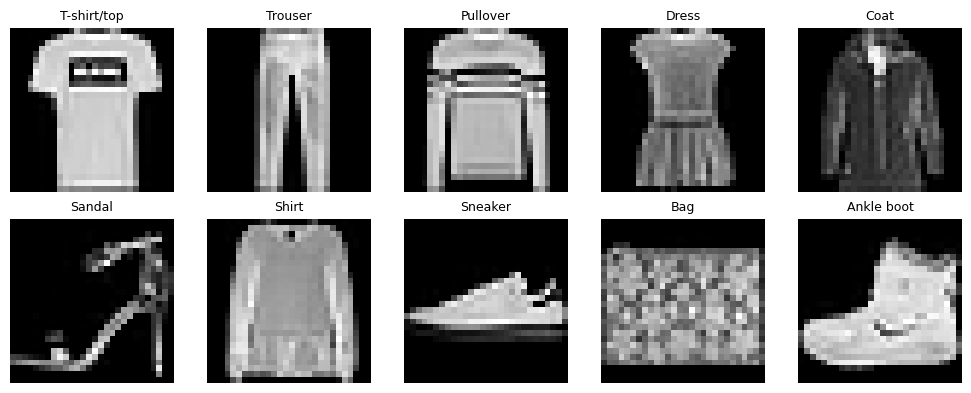

In [3]:
class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

fig,axes=plt.subplots(2,5,figsize=(10,4))
for i,ax in enumerate(axes.flat):
    idx=np.where(y_train_full==i)[0][0]
    ax.imshow(X_train_full[idx].reshape(28,28),cmap='gray')
    ax.set_title(class_names[i],fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
X_train,_,y_train,_=train_test_split(X_train_full,y_train_full,train_size=5000,stratify=y_train_full,random_state=42)
X_test,_,y_test,_=train_test_split(X_test_full,y_test_full,train_size=1000,stratify=y_test_full,random_state=42)

X_train=X_train/255.0
X_test=X_test/255.0

print(X_train.shape,X_test.shape)

(5000, 784) (1000, 784)


In [5]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

print('Accuracy :',accuracy_score(y_test,y_pred))
print('Precision:',precision_score(y_test,y_pred,average='macro'))
print('Recall   :',recall_score(y_test,y_pred,average='macro'))
print('F1-score :',f1_score(y_test,y_pred,average='macro'))
print()
print(classification_report(y_test,y_pred,target_names=class_names))

Accuracy : 0.816
Precision: 0.8214101866732616
Recall   : 0.8160000000000001
F1-score : 0.8158721271273144

              precision    recall  f1-score   support

 T-shirt/top       0.74      0.87      0.80       100
     Trouser       0.98      0.91      0.94       100
    Pullover       0.69      0.66      0.67       100
       Dress       0.85      0.90      0.87       100
        Coat       0.68      0.67      0.68       100
      Sandal       0.99      0.77      0.87       100
       Shirt       0.61      0.59      0.60       100
     Sneaker       0.80      0.94      0.87       100
         Bag       0.99      0.92      0.95       100
  Ankle boot       0.88      0.93      0.90       100

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



In [6]:
k_values=[1,3,5,7,9,11,15,21]
results=[]
for k in k_values:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    t0=time.time()
    pred=model.predict(X_test)
    pred_time=time.time()-t0
    results.append({
        'K':k,
        'Accuracy':accuracy_score(y_test,pred),
        'Precision':precision_score(y_test,pred,average='macro'),
        'Recall':recall_score(y_test,pred,average='macro'),
        'F1-score':f1_score(y_test,pred,average='macro'),
        'Prediction Time (s)':pred_time
    })

results_df=pd.DataFrame(results)
results_df

,K,Accuracy,Precision,Recall,F1-score,Prediction Time (s)
0,1,0.799,0.809072,0.799,0.799951,0.119030
1,3,0.803,0.810650,0.803,0.803153,0.128274
2,5,0.816,0.821410,0.816,0.815872,0.130624
3,7,0.808,0.812585,0.808,0.807171,0.130873
4,9,0.808,0.813039,0.808,0.807142,0.123827
5,11,0.814,0.819557,0.814,0.813557,0.132712
6,15,0.804,0.812208,0.804,0.804214,0.132664
7,21,0.802,0.808779,0.802,0.801531,0.132937


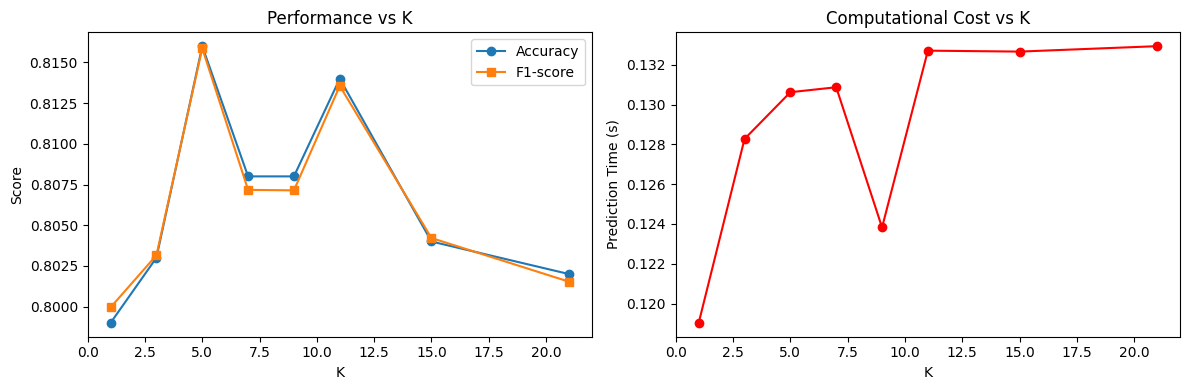

In [7]:
fig,axes=plt.subplots(1,2,figsize=(12,4))

axes[0].plot(results_df['K'],results_df['Accuracy'],marker='o',label='Accuracy')
axes[0].plot(results_df['K'],results_df['F1-score'],marker='s',label='F1-score')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Score')
axes[0].set_title('Performance vs K')
axes[0].legend()

axes[1].plot(results_df['K'],results_df['Prediction Time (s)'],marker='o',color='red')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Prediction Time (s)')
axes[1].set_title('Computational Cost vs K')

plt.tight_layout()
plt.show()

Best K: 5


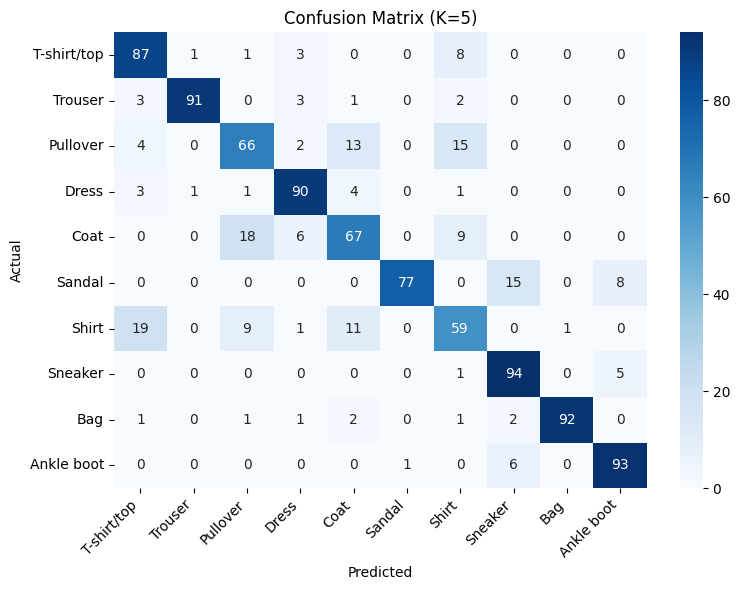

In [8]:
best_k=int(results_df.loc[results_df['Accuracy'].idxmax(),'K'])
print('Best K:',best_k)

best_model=KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train,y_train)
y_pred_best=best_model.predict(X_test)

cm=confusion_matrix(y_test,y_pred_best)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (K={best_k})')
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()